# Minimal single-cell ATAC-seq visualization using

### Install and import packages/dependencies

In [53]:
# Install 
    # pip install scanpy 
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap.umap_ as umap
import plotly.express as px

## 1. Load small built-in scRNA-seq dataset

In [54]:
data = sc.datasets.pbmc3k()

# Check loaded data
df_head = pd.DataFrame(
    data.X[:10, :10].toarray(), 
    index=data.obs_names[:10], 
    columns=data.var_names[:10]
)

df_head
# View the observations in the data
data.obs.head()

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1


## 2. Basic preprocessing for dimensionality reduction

### 2.1 Data pre-processing: 
a) Normalize

b) Log-transform

c) Select highly variable genes


In [55]:
# a) Normalize the data : normalized_counts = raw_counts / total_counts_of_cell * 10000
sc.pp.normalize_total(data, target_sum=1e4)
# b) Log-transform 
sc.pp.log1p(data)
# c) Select the top highly variable genes
    # Compute per-gene variance on the log-transformed data
data.var["log_variance"] = np.var(data.X.toarray(), axis=0)
data.var["log_variance"].describe() # check the Variance plot below
sc.pp.highly_variable_genes(data, n_top_genes=2000)
data = data[:, data.var["highly_variable"]]

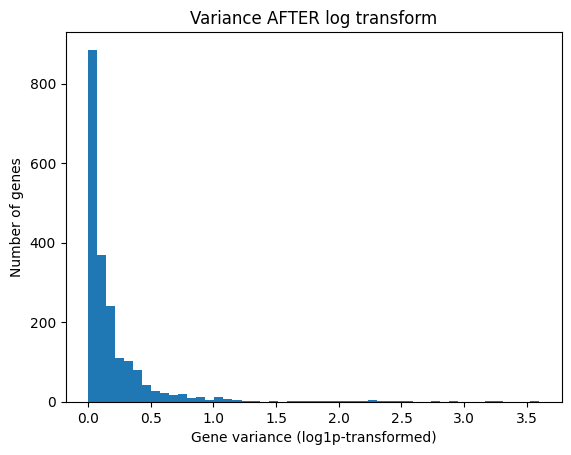

In [56]:
# plot variance
plt.hist(data.var["log_variance"], bins=50)
plt.xlabel("Gene variance (log1p-transformed)")
plt.ylabel("Number of genes")
plt.title("Variance AFTER log transform")
plt.show()

## 3. Visulaize selected genes

### 3.1 PCA 

In [57]:
X = data.X
if hasattr(X, "toarray"):   # sparse matrix
    X = X.toarray()

pca = PCA(n_components=20, random_state=0)
X_pca = pca.fit_transform(X)

print("PCA shape:", X_pca.shape)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### 3.2 UMAP embedding

In [58]:
umap_model = umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=0)
X_umap = umap_model.fit_transform(X_pca)

print("UMAP shape:", X_umap.shape)

/Users/meghnaswayambhu/miniconda3/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP shape: (2700, 2)


#### Check elbow plot to define number of clusters.

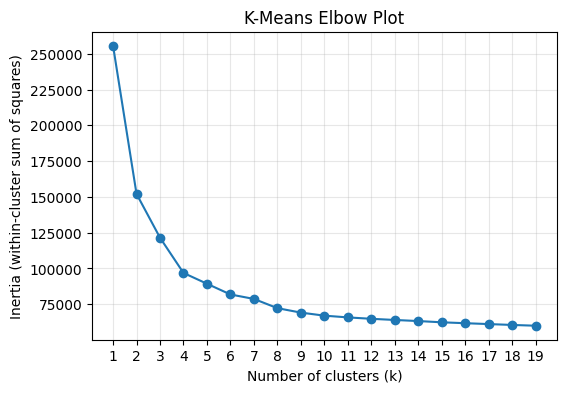

In [59]:
# Range of cluster numbers to test
K_range = range(1, 20)   # specify range

inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("K-Means Elbow Plot")
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.show()


### 3.3 Plot data: 2D

/Users/meghnaswayambhu/miniconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



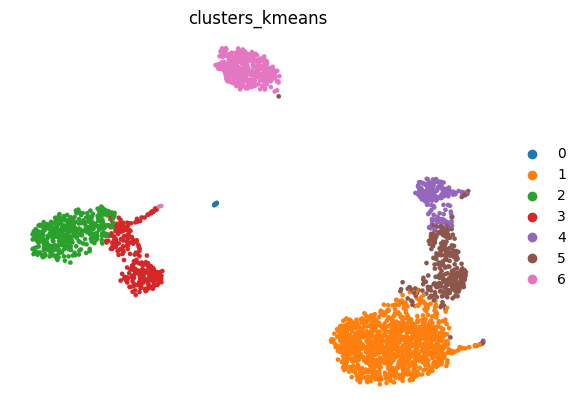

<Figure size 640x480 with 0 Axes>

In [60]:
# store in AnnData for plotting
data.obsm["X_umap_sklearn"] = X_umap

# Simple KMeans clustering in PCA space
kmeans = KMeans(n_clusters=7, random_state=0, n_init=1000)
clusters = kmeans.fit_predict(X_pca)

data.obs["clusters_kmeans"] = clusters.astype(str)
data.obs["clusters_kmeans"].value_counts()

# Use scanpy's plotting machinery but with our UMAP + clusters
sc.pl.embedding(
    data,
    basis="umap_sklearn",
    color="clusters_kmeans",
    frameon=False
)

# save the plot
plt.savefig("umap_kmeans_clusters.png", dpi=150, bbox_inches="tight")


### 3.4 Plot data: 3D and interactive

/Users/meghnaswayambhu/miniconda3/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



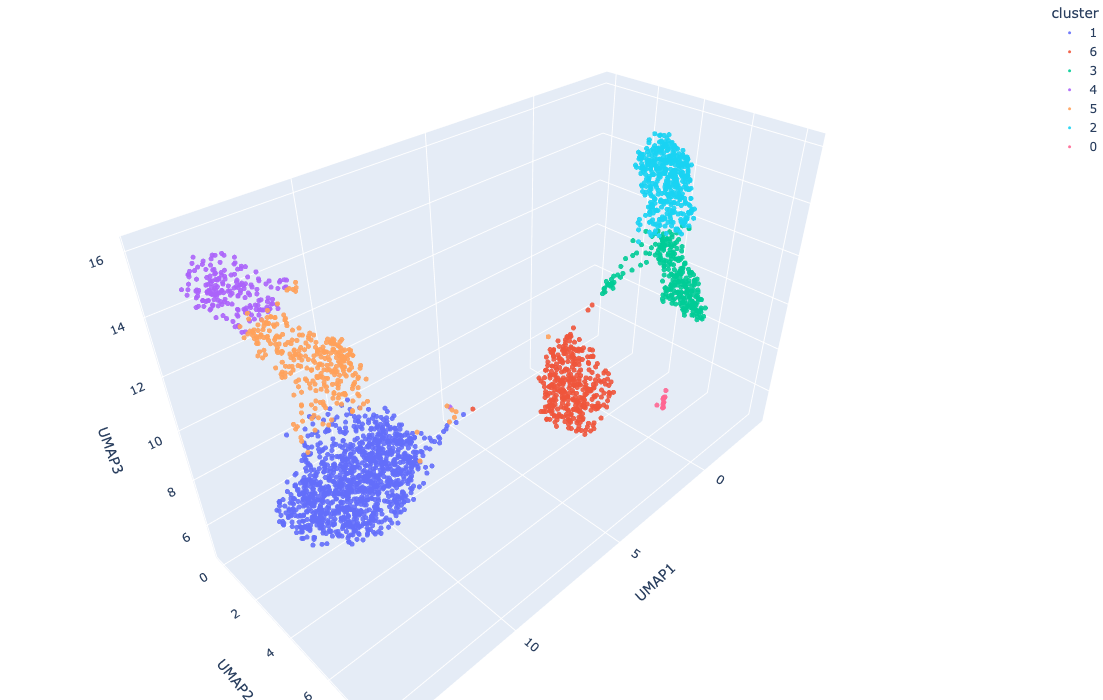

In [61]:
# Plot a 3D UMAP
umap3d = umap.UMAP(
    n_neighbors=10,
    min_dist=0.5,
    n_components=3,
    random_state=0
)

X_umap3d = umap3d.fit_transform(X_pca)
data.obsm["X_umap3d_sklearn"] = X_umap3d

# DataFrame for plotting
df_plot = pd.DataFrame(
    X_umap3d,
    columns=["UMAP1", "UMAP2", "UMAP3"]
)
df_plot["cluster"] = data.obs["clusters_kmeans"].values

fig = px.scatter_3d(
    df_plot,
    x="UMAP1",
    y="UMAP2",
    z="UMAP3",
    color="cluster",
    opacity=0.9
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(
    width=1000,
    height=700,
    margin=dict(l=0, r=0, b=0, t=0),
)
fig.show()
# save the plot
fig.write_html("umap3d_interactive.html")
